# 05 — Ablation Study: Progressive Optimisation of RoBERTa

**Goal**: Systematically measure the contribution of each training technique by changing **exactly ONE hyperparameter** per run. This produces a clean ablation table.

**Protocol**:
- **Model**: `roberta-base` (faster than ModernBERT: 72 min vs 159 min on 100K). Best config transfers to both models for full-data training.
- **Data**: 100K stratified subsample, same as NB04c baseline.
- **Duration**: 1 epoch per ablation (~25 min each). We are testing *which techniques help*, not training to convergence.
- **Metric**: Macro-F1 on 20K validation set (same split as baseline).

**Ablations**:

| # | Ablation | Change from Baseline |
|---|----------|---------------------|
| 0 | Baseline (re-run) | CE + class weights, lr=2e-5, max_len=256, warmup=10% |
| 1 | + Focal Loss (γ=2) | Replace CE with focal loss (down-weight easy examples) |
| 2 | + max_len=384 | More context — covers 95th percentile of complaint length |
| 3 | + LLRD (decay=0.95) | Layer-wise learning rate decay across 12 transformer layers |
| 4 | + Warmup 6% | Longer warmup (6% vs 10% baseline) — tests schedule sensitivity |
| 5 | Combined Best | All techniques with positive contribution |

**Hardware**: NVIDIA RTX 4060 8 GB VRAM · 64 GB RAM · AMD Ryzen 7000 · Windows 11

**Time budget**: ~2.5 hours total (5 runs × ~25 min + combined run ~35 min)

In [1]:
import os, sys, time, json, pickle, warnings, gc, copy
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok  = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
else:
    print("⚠️  No GPU — training will be very slow")
    bf16_ok = False

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
Transformers: 5.3.0
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_NAME        = "roberta-base"
MAX_TRAIN_SAMPLES = 100_000
MAX_VAL_SAMPLES   = 20_000
NUM_WORKERS       = 0 if sys.platform == "win32" else 4

# Paths — same structure as NB04c
ROOT       = Path("..").resolve()
PROCESSED  = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "models" / "ablation_study"
FIG_DIR    = ROOT / "reports" / "figures" / "nb05"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root:       {ROOT}")
print(f"Processed:  {PROCESSED}")
print(f"Output:     {OUTPUT_DIR}")
print(f"Figures:    {FIG_DIR}")

Root:       C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project
Processed:  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed
Output:     C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study
Figures:    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05


## 1 · Load Data & Tokeniser

Identical to NB04c — stratified 100K/20K subsample with the same random seed so results are directly comparable.

In [3]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")
val_df   = pd.read_parquet(PROCESSED / "val.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Classes: {n_classes}")

Train: 1,813,849  |  Val: 331,178  |  Classes: 10


In [4]:
def stratified_sample(df, max_samples, seed=42):
    """Stratified subsample preserving class ratios."""
    if max_samples is None or len(df) <= max_samples:
        return df.copy()
    frac = max_samples / len(df)
    sampled = df.groupby("product_id", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    print(f"  Sampled {len(sampled):,} / {len(df):,} rows ({frac:.1%})")
    return sampled.reset_index(drop=True)


print("Train split:")
train_sub = stratified_sample(train_df, MAX_TRAIN_SAMPLES)
print("Val split:")
val_sub = stratified_sample(val_df, MAX_VAL_SAMPLES)

del train_df, val_df
gc.collect()

# Extract text and labels
train_texts  = train_sub["narrative"].fillna("").tolist()
train_labels = train_sub["product_id"].values.tolist()
val_texts    = val_sub["narrative"].fillna("").tolist()
val_labels   = val_sub["product_id"].values.tolist()

del train_sub, val_sub
gc.collect()

print(f"\nTrain samples: {len(train_texts):,}")
print(f"Val samples:   {len(val_texts):,}")

Train split:
  Sampled 100,000 / 1,813,849 rows (5.5%)
Val split:
  Sampled 20,000 / 331,178 rows (6.0%)

Train samples: 100,000
Val samples:   20,000


In [5]:
# Class weights — computed once, reused by all ablations
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=train_labels,
)

print("Class weights:")
for sl, w in zip(short_labels, class_weights_np):
    print(f"  {sl:15s}  {w:.4f}")

Class weights:
  Bank Acct        1.3966
  Credit Card      1.0738
  Credit Report    0.1896
  Debt Collect     0.6817
  Debt Mgmt        98.0392
  Money Xfer       3.7509
  Mortgage         1.4554
  Payday/Pers      5.2466
  Student Loan     3.7965
  Vehicle Loan     5.1546


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}  vocab={tokenizer.vocab_size:,}")

Tokenizer: RobertaTokenizer  vocab=50,265


## 2 · Dataset & Loss Definitions

We define the `ComplaintDataset` (same as NB04c) plus two loss variants:
- **Weighted CrossEntropy** (baseline) — standard CE with inverse-frequency class weights
- **Focal Loss** (ablation 1) — down-weights easy examples to focus training on hard/rare cases

In [7]:
class ComplaintDataset(Dataset):
    """Lazy tokenisation dataset — identical to NB04c.
    RoBERTa does NOT use token_type_ids."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [8]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017) with optional class weights.

    Reduces the relative loss for well-classified examples, focusing
    training on hard/misclassified samples. Particularly effective for
    class-imbalanced datasets like CFPB (53% Credit Report vs 0.1% Debt Mgmt).

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    - gamma=0 recovers standard CE
    - gamma=2 is the recommended default from the paper
    - alpha provides per-class weighting (same as CE class weights)
    """

    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction
        # alpha can be a tensor of per-class weights
        if alpha is not None:
            self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        # Compute class probabilities
        log_probs = nn.functional.log_softmax(logits, dim=-1)
        probs     = torch.exp(log_probs)

        # Gather the probability of the true class
        targets_one_hot = nn.functional.one_hot(targets, num_classes=logits.size(-1)).float()
        p_t = (probs * targets_one_hot).sum(dim=-1)          # shape: (batch,)
        log_p_t = (log_probs * targets_one_hot).sum(dim=-1)  # shape: (batch,)

        # Focal modulation: (1 - p_t)^gamma
        focal_weight = (1.0 - p_t) ** self.gamma

        # Per-class alpha weighting
        if self.alpha is not None:
            alpha_t = self.alpha[targets]  # shape: (batch,)
            focal_weight = alpha_t * focal_weight

        loss = -focal_weight * log_p_t

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


print("✓ FocalLoss defined")

✓ FocalLoss defined


## 3 · Ablation Configuration

Each ablation is defined as a dataclass config. The `run_ablation()` function takes a config, builds the model/trainer/data, trains for 1 epoch, and returns metrics.

In [9]:
@dataclass
class AblationConfig:
    """Single ablation experiment configuration."""
    name:           str
    description:    str

    # Training hyperparameters
    max_seq_len:    int   = 256
    learning_rate:  float = 2e-5
    weight_decay:   float = 0.01
    warmup_ratio:   float = 0.1
    num_epochs:     int   = 1
    batch_size:     int   = 16
    grad_accum:     int   = 2

    # Ablation switches
    use_focal_loss: bool  = False
    focal_gamma:    float = 2.0
    use_llrd:       bool  = False
    llrd_decay:     float = 0.95

    # Precision (same as baseline)
    use_fp16:       bool  = True
    use_bf16:       bool  = False


# ═══════════════════════════════════════════════════════════════
#  Define all ablation experiments
# ═══════════════════════════════════════════════════════════════

ABLATIONS = [
    AblationConfig(
        name="0_baseline",
        description="Baseline (CE + class weights, lr=2e-5, max_len=256, warmup=10%)",
    ),
    AblationConfig(
        name="1_focal_loss",
        description="+ Focal Loss (gamma=2, alpha=class_weights)",
        use_focal_loss=True,
        focal_gamma=2.0,
    ),
    AblationConfig(
        name="2_max_len_384",
        description="+ max_len=384 (95th percentile coverage)",
        max_seq_len=384,
    ),
    AblationConfig(
        name="3_llrd",
        description="+ LLRD (layer-wise LR decay, factor=0.95)",
        use_llrd=True,
        llrd_decay=0.95,
    ),
    AblationConfig(
        name="4_warmup_6pct",
        description="+ Warmup 6% (vs 10% baseline)",
        warmup_ratio=0.06,
    ),
]

print(f"Defined {len(ABLATIONS)} ablation experiments:")
for cfg in ABLATIONS:
    print(f"  {cfg.name:20s} — {cfg.description}")

Defined 5 ablation experiments:
  0_baseline           — Baseline (CE + class weights, lr=2e-5, max_len=256, warmup=10%)
  1_focal_loss         — + Focal Loss (gamma=2, alpha=class_weights)
  2_max_len_384        — + max_len=384 (95th percentile coverage)
  3_llrd               — + LLRD (layer-wise LR decay, factor=0.95)
  4_warmup_6pct        — + Warmup 6% (vs 10% baseline)


## 4 · LLRD Optimiser Builder

**Layer-wise Learning Rate Decay (LLRD)** applies progressively smaller learning rates to earlier transformer layers. The intuition: earlier layers learn general linguistic features (less need to change), while later layers learn task-specific features (more need to adapt).

With `decay=0.95` and base `lr=2e-5`:
- Layer 11 (top):    2.00e-5
- Layer 6 (middle):  1.55e-5
- Layer 0 (bottom):  1.07e-5
- Embeddings:        1.02e-5

In [10]:
def get_llrd_optimizer_params(model, base_lr, decay_factor, weight_decay=0.01):
    """Build parameter groups with layer-wise learning rate decay.

    RoBERTa has:
      - roberta.embeddings.*
      - roberta.encoder.layer.{0..11}.*
      - classifier.*

    Classifier head gets the full base_lr.
    Each encoder layer gets lr * decay^(num_layers - layer_idx - 1).
    Embeddings get the smallest lr.
    """
    opt_params = []
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}

    # ── Classifier head — full learning rate ──
    classifier_params_decay    = []
    classifier_params_no_decay = []
    for name, param in model.named_parameters():
        if "classifier" in name:
            if any(nd in name for nd in no_decay):
                classifier_params_no_decay.append(param)
            else:
                classifier_params_decay.append(param)

    opt_params.append({"params": classifier_params_decay,    "lr": base_lr, "weight_decay": weight_decay})
    opt_params.append({"params": classifier_params_no_decay, "lr": base_lr, "weight_decay": 0.0})

    # ── Encoder layers — decayed learning rates ──
    num_layers = 12  # RoBERTa-base
    for layer_idx in range(num_layers - 1, -1, -1):
        layer_lr = base_lr * (decay_factor ** (num_layers - 1 - layer_idx))
        layer_prefix = f"roberta.encoder.layer.{layer_idx}."

        layer_decay    = []
        layer_no_decay = []
        for name, param in model.named_parameters():
            if name.startswith(layer_prefix):
                if any(nd in name for nd in no_decay):
                    layer_no_decay.append(param)
                else:
                    layer_decay.append(param)

        if layer_decay:
            opt_params.append({"params": layer_decay,    "lr": layer_lr, "weight_decay": weight_decay})
        if layer_no_decay:
            opt_params.append({"params": layer_no_decay, "lr": layer_lr, "weight_decay": 0.0})

    # ── Embeddings — smallest learning rate ──
    emb_lr = base_lr * (decay_factor ** num_layers)
    emb_decay    = []
    emb_no_decay = []
    for name, param in model.named_parameters():
        if "roberta.embeddings" in name:
            if any(nd in name for nd in no_decay):
                emb_no_decay.append(param)
            else:
                emb_decay.append(param)

    if emb_decay:
        opt_params.append({"params": emb_decay,    "lr": emb_lr, "weight_decay": weight_decay})
    if emb_no_decay:
        opt_params.append({"params": emb_no_decay, "lr": emb_lr, "weight_decay": 0.0})

    # Verify all parameters are assigned
    assigned = sum(len(g["params"]) for g in opt_params)
    total    = sum(1 for _ in model.parameters())
    assert assigned == total, f"Parameter mismatch: {assigned} assigned vs {total} total"

    return opt_params


# Quick preview of LR schedule
print("LLRD preview (decay=0.95, base_lr=2e-5):")
for i in range(11, -1, -1):
    lr = 2e-5 * (0.95 ** (11 - i))
    print(f"  Layer {i:2d}: {lr:.6f}")
emb_lr = 2e-5 * (0.95 ** 12)
print(f"  Embeddings: {emb_lr:.6f}")

LLRD preview (decay=0.95, base_lr=2e-5):
  Layer 11: 0.000020
  Layer 10: 0.000019
  Layer  9: 0.000018
  Layer  8: 0.000017
  Layer  7: 0.000016
  Layer  6: 0.000015
  Layer  5: 0.000015
  Layer  4: 0.000014
  Layer  3: 0.000013
  Layer  2: 0.000013
  Layer  1: 0.000012
  Layer  0: 0.000011
  Embeddings: 0.000011


## 5 · Custom Trainers

We define two Trainer subclasses:
- `WeightedCETrainer` — same as NB04c, uses `nn.CrossEntropyLoss` with class weights
- `FocalLossTrainer` — uses `FocalLoss` with class weights as alpha

For LLRD, we override `create_optimizer` to inject the custom parameter groups.

In [11]:
class WeightedCETrainer(Trainer):
    """Trainer with class-weighted CrossEntropy (baseline loss)."""

    def __init__(self, class_weights_np, llrd_config=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw_np       = class_weights_np
        self._cw_tensor   = None
        self._llrd_config = llrd_config  # dict with base_lr, decay_factor, weight_decay

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        if self._cw_tensor is None or self._cw_tensor.device != logits.device:
            self._cw_tensor = torch.tensor(
                self._cw_np, dtype=torch.float32, device=logits.device
            )

        loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        """Override to inject LLRD parameter groups if configured."""
        if self._llrd_config is not None:
            opt_params = get_llrd_optimizer_params(
                self.model,
                base_lr=self._llrd_config["base_lr"],
                decay_factor=self._llrd_config["decay_factor"],
                weight_decay=self._llrd_config["weight_decay"],
            )
            self.optimizer = torch.optim.AdamW(opt_params)
            return self.optimizer
        else:
            return super().create_optimizer()


class FocalLossTrainer(Trainer):
    """Trainer with Focal Loss (gamma=2, alpha=class_weights)."""

    def __init__(self, class_weights_np, focal_gamma=2.0, llrd_config=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw_np       = class_weights_np
        self._focal_gamma = focal_gamma
        self._focal_loss  = None
        self._llrd_config = llrd_config

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        if self._focal_loss is None or next(self._focal_loss.buffers()).device != logits.device:
            self._focal_loss = FocalLoss(
                alpha=self._cw_np, gamma=self._focal_gamma
            ).to(logits.device)

        loss = self._focal_loss(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        if self._llrd_config is not None:
            opt_params = get_llrd_optimizer_params(
                self.model,
                base_lr=self._llrd_config["base_lr"],
                decay_factor=self._llrd_config["decay_factor"],
                weight_decay=self._llrd_config["weight_decay"],
            )
            self.optimizer = torch.optim.AdamW(opt_params)
            return self.optimizer
        else:
            return super().create_optimizer()


def compute_metrics(eval_pred):
    """Compute macro-F1 and accuracy for the Trainer callback."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    accuracy = (preds == labels).mean()
    return {"macro_f1": macro_f1, "accuracy": accuracy}


print("✓ WeightedCETrainer, FocalLossTrainer, compute_metrics defined")

✓ WeightedCETrainer, FocalLossTrainer, compute_metrics defined


## 6 · Ablation Runner

The core loop: for each config, build datasets → load fresh model → train 1 epoch → evaluate → record results → clean up GPU.

In [12]:
def run_ablation(cfg: AblationConfig, run_index: int) -> Dict:
    """
    Run a single ablation experiment.

    Returns a dict with: name, description, macro_f1, accuracy, per_class_f1,
    training_time_min, and all config values.
    """
    print(f"\n{'═'*70}")
    print(f"  ABLATION {run_index}/{len(ABLATIONS)-1}: {cfg.name}")
    print(f"  {cfg.description}")
    print(f"{'═'*70}")

    # ── 1. Build datasets with this config's max_seq_len ──
    train_ds = ComplaintDataset(train_texts, train_labels, tokenizer, cfg.max_seq_len)
    val_ds   = ComplaintDataset(val_texts,   val_labels,   tokenizer, cfg.max_seq_len)
    print(f"  Datasets: {len(train_ds):,} train, {len(val_ds):,} val, max_len={cfg.max_seq_len}")

    # ── 2. Load fresh model ──
    torch.cuda.empty_cache()
    gc.collect()

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=n_classes,
        problem_type="single_label_classification",
    )
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    print(f"  Model loaded: {MODEL_NAME} ({sum(p.numel() for p in model.parameters())/1e6:.1f}M params)")

    # ── 3. Training args ──
    steps_per_epoch = len(train_ds) // (cfg.batch_size * cfg.grad_accum)
    eval_steps = max(steps_per_epoch // 2, 100)

    run_output = OUTPUT_DIR / cfg.name
    run_output.mkdir(parents=True, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=str(run_output / "checkpoints"),
        num_train_epochs=cfg.num_epochs,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        warmup_ratio=cfg.warmup_ratio,
        lr_scheduler_type="cosine",

        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size * 2,
        gradient_accumulation_steps=cfg.grad_accum,

        bf16=cfg.use_bf16,
        fp16=cfg.use_fp16,

        eval_strategy="steps",
        eval_steps=eval_steps,
        save_strategy="steps",
        save_steps=eval_steps,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        logging_steps=max(steps_per_epoch // 5, 50),
        report_to="none",
        seed=SEED,
        dataloader_num_workers=NUM_WORKERS,
        dataloader_pin_memory=(NUM_WORKERS > 0),
    )

    # ── 4. Build LLRD config if needed ──
    llrd_config = None
    if cfg.use_llrd:
        llrd_config = {
            "base_lr": cfg.learning_rate,
            "decay_factor": cfg.llrd_decay,
            "weight_decay": cfg.weight_decay,
        }
        print(f"  LLRD enabled: decay={cfg.llrd_decay}, base_lr={cfg.learning_rate}")

    # ── 5. Build trainer ──
    if cfg.use_focal_loss:
        trainer = FocalLossTrainer(
            class_weights_np=class_weights_np,
            focal_gamma=cfg.focal_gamma,
            llrd_config=llrd_config,
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
        )
        print(f"  Loss: Focal Loss (gamma={cfg.focal_gamma})")
    else:
        trainer = WeightedCETrainer(
            class_weights_np=class_weights_np,
            llrd_config=llrd_config,
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
        )
        print(f"  Loss: Weighted CrossEntropy")

    # ── 6. Train ──
    print(f"  Training: {cfg.num_epochs} epoch, {steps_per_epoch:,} steps/epoch, eval every {eval_steps:,} steps")
    t0 = time.time()
    train_result = trainer.train()
    elapsed = time.time() - t0
    print(f"  ✓ Training complete in {elapsed/60:.1f} min (loss={train_result.training_loss:.4f})")

    # ── 7. Evaluate on validation set ──
    print(f"  Evaluating best checkpoint...")
    predictions = trainer.predict(val_ds)
    logits  = predictions.predictions
    y_true  = predictions.label_ids
    y_pred  = np.argmax(logits, axis=-1)

    # Sanity checks
    assert not np.isnan(logits).any(), f"NaN in logits for {cfg.name}"
    assert len(np.unique(y_pred)) > 1, f"Single-class prediction in {cfg.name}"

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    accuracy = (y_true == y_pred).mean()
    per_class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"  ══ Results: Macro-F1={macro_f1:.4f}  Accuracy={accuracy:.4f} ══")

    # ── 8. Extract training history ──
    train_logs = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
    eval_logs  = [l for l in trainer.state.log_history if "eval_macro_f1" in l]

    # ── 9. Build result dict ──
    result = {
        "name":             cfg.name,
        "description":      cfg.description,
        "macro_f1":         float(macro_f1),
        "accuracy":         float(accuracy),
        "per_class_f1":     {sl: float(per_class_f1[i]) for i, sl in enumerate(short_labels)},
        "training_time_min": round(elapsed / 60, 1),
        "train_loss_final":  float(train_result.training_loss),
        "config":           asdict(cfg),
        "train_logs":       train_logs,
        "eval_logs":        eval_logs,
    }

    # Save individual result
    with open(run_output / "result.json", "w") as f:
        json.dump(result, f, indent=2)

    # ── 10. Cleanup ──
    del model, trainer, train_ds, val_ds, predictions, logits
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU memory released.")

    return result


print("✓ run_ablation() defined")

✓ run_ablation() defined


## 7 · Run All Ablations

Each run takes ~25 min (1 epoch on 100K). Total: ~2 hours for 5 runs.

In [13]:
all_results = []
total_t0 = time.time()

for i, cfg in enumerate(ABLATIONS):
    result = run_ablation(cfg, run_index=i)
    all_results.append(result)

    # Progress summary after each run
    print(f"\n  Progress: {i+1}/{len(ABLATIONS)} complete")
    print(f"  {'Ablation':25s}  {'Macro-F1':>9s}  {'Δ Baseline':>10s}  {'Time':>8s}")
    print(f"  {'-'*57}")
    baseline_f1 = all_results[0]["macro_f1"]
    for r in all_results:
        delta = r["macro_f1"] - baseline_f1
        sign  = "+" if delta >= 0 else ""
        print(f"  {r['name']:25s}  {r['macro_f1']:>9.4f}  {sign}{delta:>9.4f}  {r['training_time_min']:>6.1f} m")

total_elapsed = (time.time() - total_t0) / 60
print(f"\n{'='*60}")
print(f"  ALL ABLATIONS COMPLETE — Total time: {total_elapsed:.1f} min")
print(f"{'='*60}")


══════════════════════════════════════════════════════════════════════
  ABLATION 0/4: 0_baseline
  Baseline (CE + class weights, lr=2e-5, max_len=256, warmup=10%)
══════════════════════════════════════════════════════════════════════
  Datasets: 100,000 train, 20,000 val, max_len=256


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Model loaded: roberta-base (124.7M params)
  Loss: Weighted CrossEntropy
  Training: 1 epoch, 3,125 steps/epoch, eval every 1,562 steps


Step,Training Loss,Validation Loss,Macro F1,Accuracy
1562,1.607854,0.544773,0.653669,0.835900
3124,1.437365,0.530505,0.668080,0.838400


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  ✓ Training complete in 23.7 min (loss=1.6712)
  Evaluating best checkpoint...


  ══ Results: Macro-F1=0.6670  Accuracy=0.8359 ══
  GPU memory released.

  Progress: 5/5 complete
  Ablation                    Macro-F1  Δ Baseline      Time
  ---------------------------------------------------------
  0_baseline                    0.6681  +   0.0000    24.0 m
  1_focal_loss                  0.6648    -0.0033    23.8 m
  2_max_len_384                 0.6694  +   0.0013    35.8 m
  3_llrd                        0.6644    -0.0037    24.7 m
  4_warmup_6pct                 0.6670    -0.0011    23.7 m

  ALL ABLATIONS COMPLETE — Total time: 138.1 min


## 8 · Determine Best Combination

Any ablation that improved macro-F1 over baseline gets included in the combined config.

In [15]:
baseline_f1 = all_results[0]["macro_f1"]

print(f"Baseline Macro-F1: {baseline_f1:.4f}\n")
print(f"{'Ablation':25s}  {'Macro-F1':>9s}  {'Δ':>9s}  {'Include?':>9s}")
print("-" * 60)

positive_ablations = []
for r in all_results[1:]:  # skip baseline
    delta = r["macro_f1"] - baseline_f1
    include = delta > 0
    marker = "✓ YES" if include else "✗ no"
    print(f"{r['name']:25s}  {r['macro_f1']:>9.4f}  {delta:>+9.4f}  {marker:>9s}")
    if include:
        positive_ablations.append(r)

print(f"\nPositive techniques: {len(positive_ablations)} / {len(all_results)-1}")
for r in positive_ablations:
    print(f"  → {r['description']}")

Baseline Macro-F1: 0.6681

Ablation                    Macro-F1          Δ   Include?
------------------------------------------------------------
1_focal_loss                  0.6648    -0.0033       ✗ no
2_max_len_384                 0.6694    +0.0013      ✓ YES
3_llrd                        0.6644    -0.0037       ✗ no
4_warmup_6pct                 0.6670    -0.0011       ✗ no

Positive techniques: 1 / 4
  → + max_len=384 (95th percentile coverage)


In [16]:
# ═══════════════════════════════════════════════════════════════
#  Build combined config from positive ablations
# ═══════════════════════════════════════════════════════════════

combined_cfg = AblationConfig(
    name="5_combined_best",
    description="Combined: all positive-contribution techniques",
)

# Start from baseline defaults, then layer on each positive technique
positive_names = {r["name"] for r in positive_ablations}

if "1_focal_loss" in positive_names:
    combined_cfg.use_focal_loss = True
    combined_cfg.focal_gamma = 2.0
    print("  Including: Focal Loss (gamma=2)")

if "2_max_len_384" in positive_names:
    combined_cfg.max_seq_len = 384
    print("  Including: max_len=384")

if "3_llrd" in positive_names:
    combined_cfg.use_llrd = True
    combined_cfg.llrd_decay = 0.95
    print("  Including: LLRD (decay=0.95)")

if "4_warmup_6pct" in positive_names:
    combined_cfg.warmup_ratio = 0.06
    print("  Including: warmup=6%")

if len(positive_ablations) == 0:
    print("  No positive ablations — combined config is identical to baseline.")
    print("  Skipping combined run.")
    combined_cfg = None

# Update description to list included techniques
if combined_cfg is not None:
    parts = [r["description"].replace("+ ", "") for r in positive_ablations]
    combined_cfg.description = "Combined: " + " + ".join(parts)
    print(f"\nCombined config: {combined_cfg.description}")

  Including: max_len=384

Combined config: Combined: max_len=384 (95th percentile coverage)


In [17]:
# Run the combined experiment
if combined_cfg is not None:
    combined_result = run_ablation(combined_cfg, run_index=len(ABLATIONS))
    all_results.append(combined_result)
    print(f"\n  Combined Macro-F1: {combined_result['macro_f1']:.4f}")
    print(f"  Δ vs baseline:     {combined_result['macro_f1'] - baseline_f1:+.4f}")
else:
    print("Combined run skipped — no positive ablations.")


══════════════════════════════════════════════════════════════════════
  ABLATION 5/4: 5_combined_best
  Combined: max_len=384 (95th percentile coverage)
══════════════════════════════════════════════════════════════════════
  Datasets: 100,000 train, 20,000 val, max_len=384


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Model loaded: roberta-base (124.7M params)
  Loss: Weighted CrossEntropy
  Training: 1 epoch, 3,125 steps/epoch, eval every 1,562 steps


Step,Training Loss,Validation Loss,Macro F1,Accuracy
1562,1.596650,0.545118,0.657362,0.836950
3124,1.410295,0.525794,0.672631,0.840600


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  ✓ Training complete in 36.2 min (loss=1.6966)
  Evaluating best checkpoint...


  ══ Results: Macro-F1=0.6726  Accuracy=0.8406 ══
  GPU memory released.

  Combined Macro-F1: 0.6726
  Δ vs baseline:     +0.0046


## 9 · Results Table

The clean ablation table — goes directly into the vlog and the NB10 comprehensive evaluation.

In [18]:
# ═══════════════════════════════════════════════════════════════
#  Final Ablation Table
# ═══════════════════════════════════════════════════════════════

baseline_f1 = all_results[0]["macro_f1"]

# Include the 3-epoch baseline from NB04c for context
nb04c_results_path = ROOT / "models" / "roberta_base" / "roberta_results.json"
if nb04c_results_path.exists():
    with open(nb04c_results_path) as f:
        nb04c = json.load(f)
    nb04c_f1 = nb04c["macro_f1"]
else:
    nb04c_f1 = 0.7097  # from baseline run

print(f"\n{'='*80}")
print(f"  ABLATION STUDY RESULTS — RoBERTa-base on 100K Subsample")
print(f"{'='*80}")
print(f"\n  Reference: NB04c RoBERTa baseline (3 epochs): Macro-F1 = {nb04c_f1:.4f}")
print(f"  Reference: LogReg + TF-IDF baseline:            Macro-F1 = 0.7543")
print()

print(f"  {'#':>2s}  {'Ablation':30s}  {'Macro-F1':>9s}  {'Δ Baseline':>11s}  {'Time':>7s}")
print(f"  {'─'*66}")

for i, r in enumerate(all_results):
    delta = r["macro_f1"] - baseline_f1
    delta_str = f"{delta:+.4f}" if i > 0 else "—"
    marker = "" if i == 0 else (" ▲" if delta > 0 else " ▼" if delta < 0 else " ═")
    print(f"  {i:>2d}  {r['name']:30s}  {r['macro_f1']:>9.4f}  {delta_str:>11s}{marker}  {r['training_time_min']:>5.1f} m")

print(f"  {'─'*66}")

# Identify the best
best = max(all_results, key=lambda r: r["macro_f1"])
print(f"\n  ★ Best config: {best['name']} (Macro-F1 = {best['macro_f1']:.4f})")
print(f"    → This config will be used for full-data training in NB06a and NB06b.")


  ABLATION STUDY RESULTS — RoBERTa-base on 100K Subsample

  Reference: NB04c RoBERTa baseline (3 epochs): Macro-F1 = 0.7097
  Reference: LogReg + TF-IDF baseline:            Macro-F1 = 0.7543

   #  Ablation                         Macro-F1   Δ Baseline     Time
  ──────────────────────────────────────────────────────────────────
   0  0_baseline                         0.6681            —   24.0 m
   1  1_focal_loss                       0.6648      -0.0033 ▼   23.8 m
   2  2_max_len_384                      0.6694      +0.0013 ▲   35.8 m
   3  3_llrd                             0.6644      -0.0037 ▼   24.7 m
   4  4_warmup_6pct                      0.6670      -0.0011 ▼   23.7 m
   5  5_combined_best                    0.6726      +0.0046 ▲   36.2 m
  ──────────────────────────────────────────────────────────────────

  ★ Best config: 5_combined_best (Macro-F1 = 0.6726)
    → This config will be used for full-data training in NB06a and NB06b.


In [19]:
# Per-class comparison: baseline vs best ablation
best_per_class = best["per_class_f1"]
base_per_class = all_results[0]["per_class_f1"]

print(f"\n  Per-Class F1: Baseline vs {best['name']}")
print(f"  {'Class':15s}  {'Baseline':>9s}  {'Best':>9s}  {'Δ':>8s}")
print(f"  {'-'*47}")

for sl in short_labels:
    b = base_per_class[sl]
    a = best_per_class[sl]
    delta = a - b
    marker = "▲" if delta > 0.005 else "▼" if delta < -0.005 else "═"
    print(f"  {sl:15s}  {b:>9.4f}  {a:>9.4f}  {delta:>+7.4f} {marker}")

print(f"  {'-'*47}")
print(f"  {'Macro':15s}  {all_results[0]['macro_f1']:>9.4f}  {best['macro_f1']:>9.4f}  {best['macro_f1']-all_results[0]['macro_f1']:>+7.4f}")


  Per-Class F1: Baseline vs 5_combined_best
  Class             Baseline       Best         Δ
  -----------------------------------------------
  Bank Acct           0.8190     0.8150  -0.0040 ═
  Credit Card         0.7112     0.7133  +0.0021 ═
  Credit Report       0.9058     0.9069  +0.0011 ═
  Debt Collect        0.6874     0.6941  +0.0067 ▲
  Debt Mgmt           0.0000     0.0000  +0.0000 ═
  Money Xfer          0.8865     0.8881  +0.0016 ═
  Mortgage            0.8281     0.8379  +0.0098 ▲
  Payday/Pers         0.4695     0.4846  +0.0151 ▲
  Student Loan        0.7381     0.7538  +0.0157 ▲
  Vehicle Loan        0.6352     0.6325  -0.0027 ═
  -----------------------------------------------
  Macro               0.6681     0.6726  +0.0046


## 10 · Visualisations

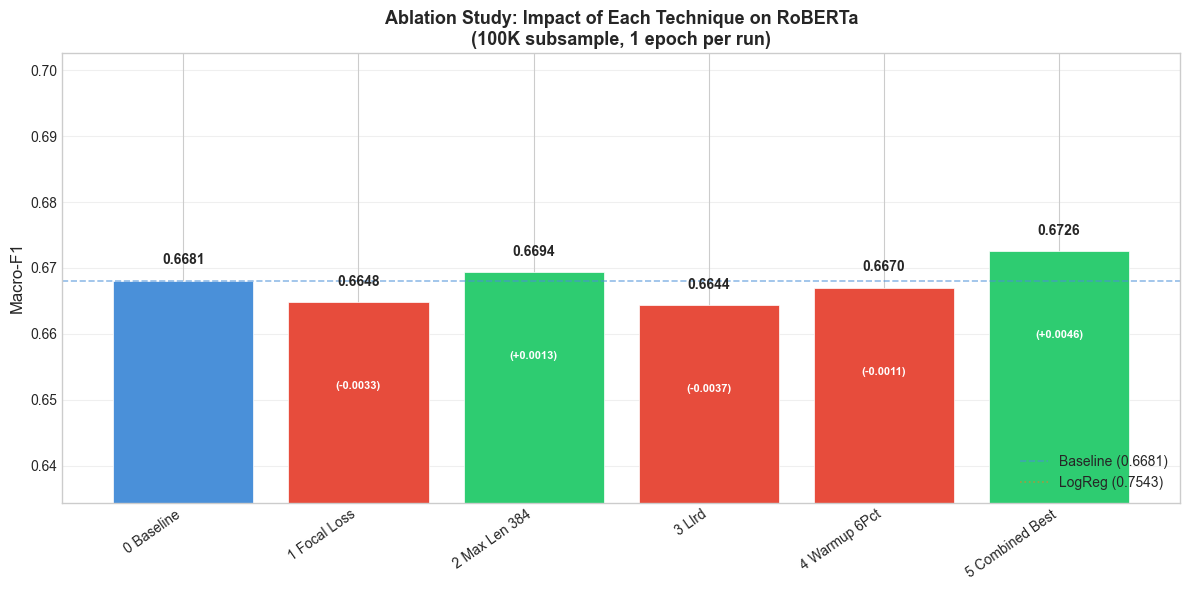

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05\ablation_bar_chart.png


In [20]:
# ═══════════════════════════════════════════════════════════════
#  Figure 1: Ablation Bar Chart (macro-F1)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

names  = [r["name"].replace("_", " ").title() for r in all_results]
f1s    = [r["macro_f1"] for r in all_results]
deltas = [r["macro_f1"] - baseline_f1 for r in all_results]

# Color: green if above baseline, red if below, blue for baseline
colors = []
for i, d in enumerate(deltas):
    if i == 0:
        colors.append("#4A90D9")   # blue for baseline
    elif d > 0:
        colors.append("#2ECC71")   # green for positive
    elif d < 0:
        colors.append("#E74C3C")   # red for negative
    else:
        colors.append("#95A5A6")   # grey for neutral

bars = ax.bar(range(len(all_results)), f1s, color=colors, edgecolor="white", linewidth=0.5)

# Baseline reference line
ax.axhline(y=baseline_f1, color="#4A90D9", linestyle="--", alpha=0.6, linewidth=1.2, label=f"Baseline ({baseline_f1:.4f})")

# LogReg reference line
ax.axhline(y=0.7543, color="#E67E22", linestyle=":", alpha=0.6, linewidth=1.2, label="LogReg (0.7543)")

# Value labels on bars
for i, (bar, f1, delta) in enumerate(zip(bars, f1s, deltas)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{f1:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    if i > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.012,
                f"({delta:+.4f})", ha="center", va="top", fontsize=8, color="white", fontweight="bold")

ax.set_xticks(range(len(all_results)))
ax.set_xticklabels(names, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Macro-F1", fontsize=12)
ax.set_title("Ablation Study: Impact of Each Technique on RoBERTa\n(100K subsample, 1 epoch per run)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Dynamic y-axis: show meaningful differences
y_min = min(f1s) - 0.03
y_max = max(f1s) + 0.03
ax.set_ylim(max(0, y_min), min(1.0, y_max))

plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'ablation_bar_chart.png'}")

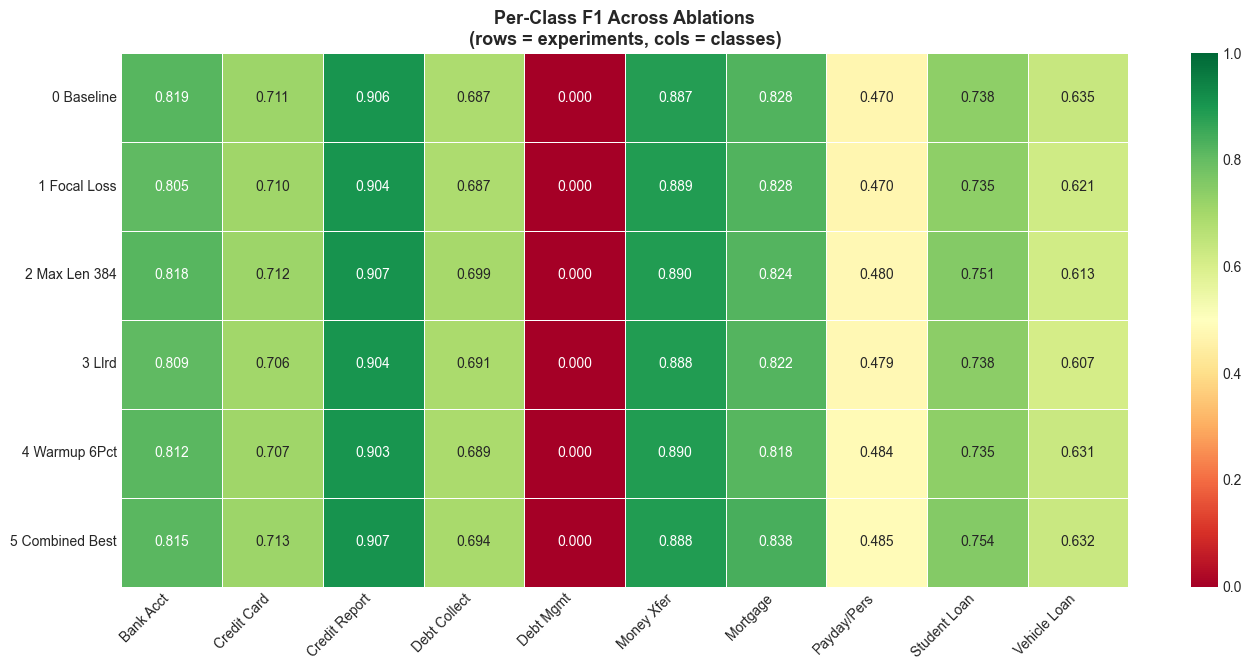

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05\ablation_per_class_heatmap.png


In [21]:
# ═══════════════════════════════════════════════════════════════
#  Figure 2: Per-Class F1 Heatmap — All Ablations
# ═══════════════════════════════════════════════════════════════

# Build a matrix: rows = ablations, cols = classes
f1_matrix = []
row_labels = []
for r in all_results:
    row = [r["per_class_f1"][sl] for sl in short_labels]
    f1_matrix.append(row)
    row_labels.append(r["name"].replace("_", " ").title())

f1_df = pd.DataFrame(f1_matrix, index=row_labels, columns=short_labels)

fig, ax = plt.subplots(figsize=(14, max(4, len(all_results) * 0.8 + 2)))
sns.heatmap(
    f1_df, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.0, vmax=1.0,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Per-Class F1 Across Ablations\n(rows = experiments, cols = classes)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_per_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'ablation_per_class_heatmap.png'}")

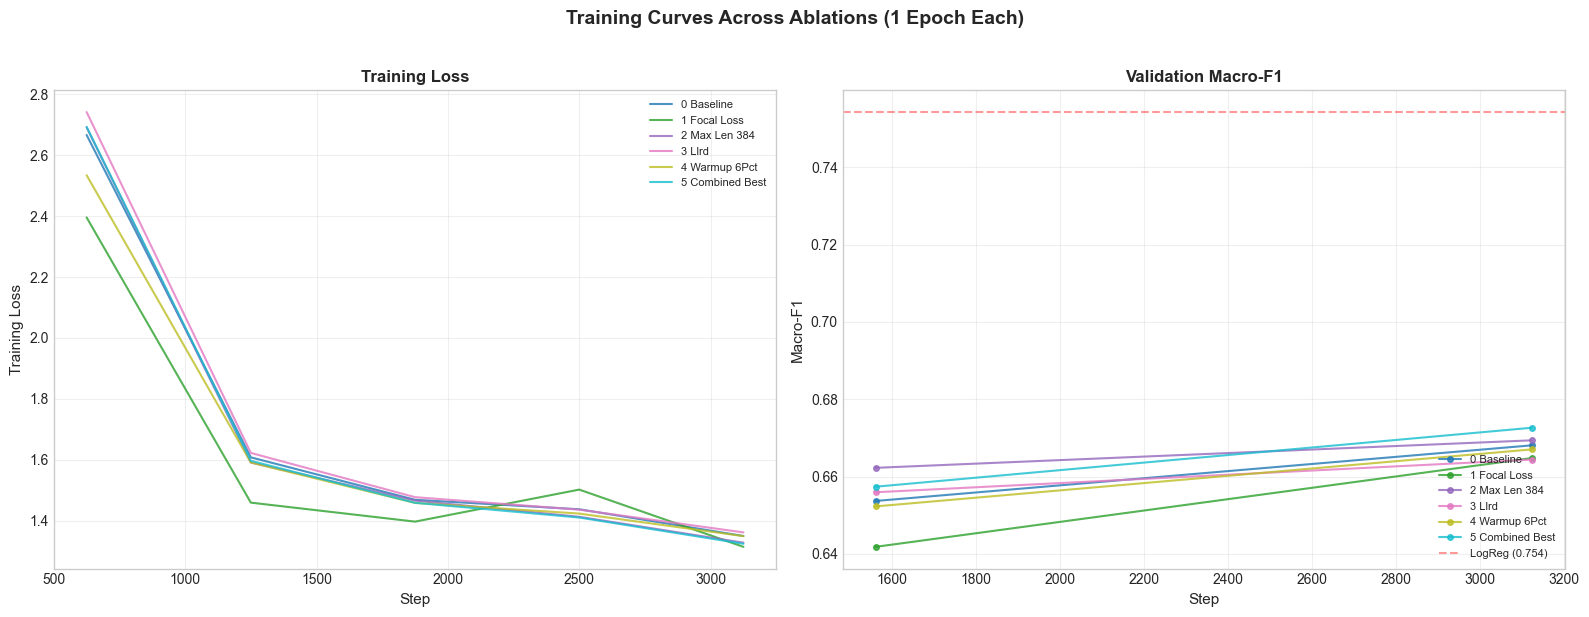

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05\ablation_training_curves.png


In [22]:
# ═══════════════════════════════════════════════════════════════
#  Figure 3: Training Loss Curves — All Ablations Overlaid
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

# Panel 1: Training loss
ax = axes[0]
for i, r in enumerate(all_results):
    logs = r["train_logs"]
    if logs:
        steps  = [l["step"] for l in logs]
        losses = [l["loss"] for l in logs]
        ax.plot(steps, losses, color=palette[i], alpha=0.8, linewidth=1.5,
                label=r["name"].replace("_", " ").title())
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Training Loss", fontsize=11)
ax.set_title("Training Loss", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

# Panel 2: Validation Macro-F1
ax = axes[1]
for i, r in enumerate(all_results):
    logs = r["eval_logs"]
    if logs:
        steps = [l["step"] for l in logs]
        f1s   = [l["eval_macro_f1"] for l in logs]
        ax.plot(steps, f1s, color=palette[i], alpha=0.8, linewidth=1.5,
                marker="o", markersize=4,
                label=r["name"].replace("_", " ").title())

ax.axhline(y=0.7543, color="red", linestyle="--", alpha=0.4, label="LogReg (0.754)")
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Macro-F1", fontsize=11)
ax.set_title("Validation Macro-F1", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

plt.suptitle("Training Curves Across Ablations (1 Epoch Each)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'ablation_training_curves.png'}")

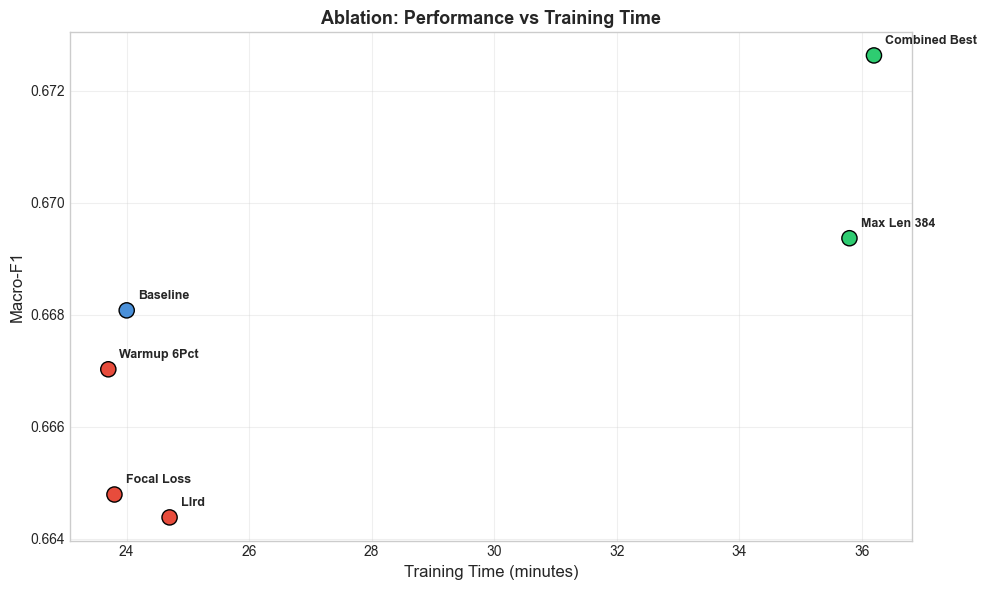

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05\ablation_time_vs_performance.png


In [23]:
# ═══════════════════════════════════════════════════════════════
#  Figure 4: Time vs Performance Scatter
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

times = [r["training_time_min"] for r in all_results]
f1s   = [r["macro_f1"] for r in all_results]
names_short = [r["name"].split("_", 1)[1].replace("_", " ").title() if "_" in r["name"] else r["name"]
               for r in all_results]

scatter = ax.scatter(times, f1s, s=120, c=colors, edgecolors="black", linewidths=1, zorder=5)

for i, (t, f1, name) in enumerate(zip(times, f1s, names_short)):
    ax.annotate(name, (t, f1), textcoords="offset points",
                xytext=(8, 8), fontsize=9, fontweight="bold")

ax.set_xlabel("Training Time (minutes)", fontsize=12)
ax.set_ylabel("Macro-F1", fontsize=12)
ax.set_title("Ablation: Performance vs Training Time", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_time_vs_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'ablation_time_vs_performance.png'}")

## 11 · Save Final Outputs

Save everything needed by downstream notebooks:
- Ablation results table (JSON) → NB10 evaluation
- Best config (JSON) → NB06a/06b full-data training
- Figures → vlog

In [24]:
# ── Save all ablation results ──
ablation_summary = {
    "experiment": "ablation_study",
    "model": MODEL_NAME,
    "data_subsample": MAX_TRAIN_SAMPLES,
    "epochs_per_run": 1,
    "seed": SEED,
    "nb04c_baseline_3epoch_f1": nb04c_f1,
    "logreg_baseline_f1": 0.7543,
    "results": [
        {
            "name":             r["name"],
            "description":      r["description"],
            "macro_f1":         r["macro_f1"],
            "accuracy":         r["accuracy"],
            "per_class_f1":     r["per_class_f1"],
            "training_time_min": r["training_time_min"],
            "delta_vs_baseline": round(r["macro_f1"] - all_results[0]["macro_f1"], 5),
        }
        for r in all_results
    ],
}

summary_path = OUTPUT_DIR / "ablation_summary.json"
with open(summary_path, "w") as f:
    json.dump(ablation_summary, f, indent=2)
print(f"✓ Ablation summary saved: {summary_path}")

# ── Save best config for NB06a/06b ──
best_config = asdict(best["config"]) if isinstance(best.get("config"), AblationConfig) else best.get("config", {})

# If the best was one of the individual ablations (not combined), wrap it
best_config_output = {
    "source": "nb05_ablation_study",
    "best_ablation_name": best["name"],
    "best_macro_f1": best["macro_f1"],
    "config": best_config,
    "notes": "Apply this config to both RoBERTa and ModernBERT for full-data training (NB06a/06b).",
}

best_config_path = OUTPUT_DIR / "best_config.json"
with open(best_config_path, "w") as f:
    json.dump(best_config_output, f, indent=2)
print(f"✓ Best config saved: {best_config_path}")
print(f"  → Use this in NB06a and NB06b for full-data training.")

# ── Also save as CSV for easy viewing ──
rows = []
for r in all_results:
    rows.append({
        "Ablation": r["name"],
        "Description": r["description"],
        "Macro_F1": round(r["macro_f1"], 4),
        "Delta": round(r["macro_f1"] - all_results[0]["macro_f1"], 4),
        "Accuracy": round(r["accuracy"], 4),
        "Time_min": r["training_time_min"],
    })

results_df = pd.DataFrame(rows)
csv_path = OUTPUT_DIR / "ablation_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"✓ Results CSV saved: {csv_path}")
print()
print(results_df.to_string(index=False))

✓ Ablation summary saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\ablation_summary.json
✓ Best config saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\best_config.json
  → Use this in NB06a and NB06b for full-data training.
✓ Results CSV saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\ablation_results.csv

       Ablation                                                     Description  Macro_F1   Delta  Accuracy  Time_min
     0_baseline Baseline (CE + class weights, lr=2e-5, max_len=256, warmup=10%)    0.6681  0.0000    0.8384      24.0
   1_focal_loss                     + Focal Loss (gamma=2, alpha=class_weights)    0.6648 -0.0033    0.8358      23.8
  2_max_len_384                        + max_len=384 (95th percentile coverage)    0.6694  0.0013    0.8407      35.8
         3_llrd                       + LLRD (layer-wise LR decay, factor=0.95)    0.664

In [25]:
# ── Print final summary ──
print(f"\n{'═'*70}")
print(f"  ABLATION STUDY COMPLETE")
print(f"{'═'*70}")
print(f"\n  Total runs:     {len(all_results)}")
print(f"  Best config:    {best['name']}")
print(f"  Best Macro-F1:  {best['macro_f1']:.4f}")
print(f"  Δ vs baseline:  {best['macro_f1'] - all_results[0]['macro_f1']:+.4f}")
print()
print(f"  Outputs:")
print(f"    {summary_path}")
print(f"    {best_config_path}")
print(f"    {csv_path}")
print(f"    {FIG_DIR}/  (4 figures)")
print()
print(f"  Next steps:")
print(f"    → NB06a: RoBERTa full-data training with best config (8-10 epochs + early stopping)")
print(f"    → NB06b: ModernBERT full-data training with best config (epoch cap from NB06a)")
print(f"    → NB07:  Ensemble (soft voting + learned stacking from saved predictions)")
print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  ABLATION STUDY COMPLETE
══════════════════════════════════════════════════════════════════════

  Total runs:     6
  Best config:    5_combined_best
  Best Macro-F1:  0.6726
  Δ vs baseline:  +0.0046

  Outputs:
    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\ablation_summary.json
    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\best_config.json
    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ablation_study\ablation_results.csv
    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb05/  (4 figures)

  Next steps:
    → NB06a: RoBERTa full-data training with best config (8-10 epochs + early stopping)
    → NB06b: ModernBERT full-data training with best config (epoch cap from NB06a)
    → NB07:  Ensemble (soft voting + learned stacking from saved predictions)

═══════════════════